In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
df=pd.read_csv("/content/final_dataset.csv")
df.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


In [64]:
df['emotion'].value_counts()

,count
emotion,
fun,10000
surprise,10000
enthusiasm,10000
anger,10000
happiness,10000
hate,10000
love,10000
relief,10000
sadness,9999


In [65]:
df.isna().sum()

,0
text,0
emotion,0


In [66]:
df.dropna(inplace=True)

In [67]:
df.isna().sum()

,0
text,0
emotion,0


In [68]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [69]:
df["text"] = df["text"].astype(str)


df["clean_text"] = (
    df["text"]
    .str.lower()
    .str.replace(r'[^a-zA-Z\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [70]:
df.head()

,text,emotion,clean_text
0,i feel rather funny ending with so many dupes ...,fun,i feel rather funny ending with so many dupes ...
1,i feel surprised by the result,surprise,i feel surprised by the result
2,i am officially feeling festive,neutral,i am officially feeling festive
3,i suddenly found myself standing before this w...,surprise,i suddenly found myself standing before this w...
4,i look at the meager pile of food i purchased ...,enthusiasm,i look at the meager pile of food i purchased ...


In [71]:
print(df['text'][0])

i feel rather funny ending with so many dupes while i always prefer originals


In [72]:
print(df['clean_text'][0])

i feel rather funny ending with so many dupes while i always prefer originals


In [73]:
X=df["clean_text"]
y=df["emotion"]

In [74]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english"
)

In [76]:
X_train = tfidf.fit_transform(X_train)


X_test = tfidf.transform(X_test)

In [77]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [78]:
from sklearn.metrics import accuracy_score,classification_report
y_pred=lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8172159277890085

Classification Report:
              precision    recall  f1-score   support

       anger       0.88      0.85      0.87      2002
       empty       0.86      0.62      0.72      1278
  enthusiasm       0.98      0.91      0.94      1999
         fun       0.92      0.84      0.88      1974
   happiness       0.73      0.75      0.74      2004
        hate       0.93      0.80      0.86      2032
        love       0.91      0.90      0.90      1969
     neutral       0.70      0.91      0.79      1970
      relief       0.94      0.86      0.89      2017
     sadness       0.61      0.73      0.66      1965
    surprise       0.70      0.76      0.73      2061

    accuracy                           0.82     21271
   macro avg       0.83      0.81      0.82     21271
weighted avg       0.83      0.82      0.82     21271



<Axes: >

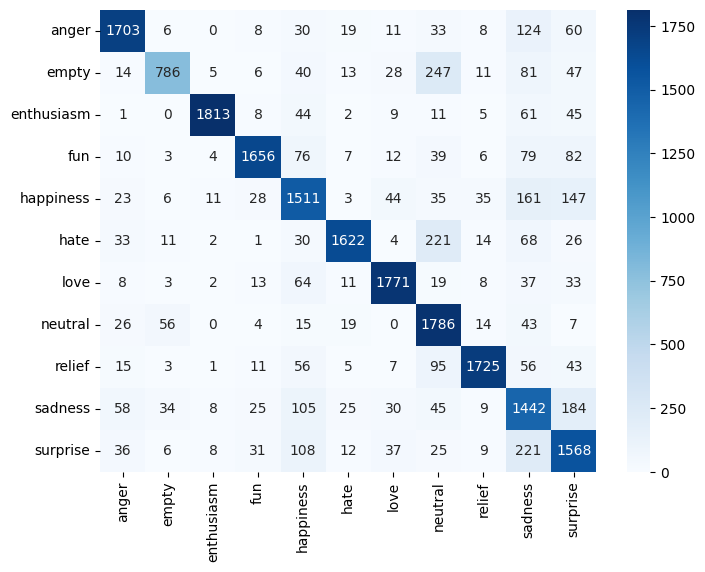

In [79]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lr.classes_, yticklabels=lr.classes_)

In [80]:
df["text"].size

106355

In [81]:
from sklearn.svm import LinearSVC
svc=LinearSVC(  )
svc.fit(X_train,y_train)


LinearSVC()

In [82]:
y_pred2=svc.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Accuracy: 0.8249259555263034

Classification Report:
              precision    recall  f1-score   support

       anger       0.86      0.86      0.86      2002
       empty       0.81      0.73      0.77      1278
  enthusiasm       0.96      0.92      0.94      1999
         fun       0.90      0.87      0.88      1974
   happiness       0.72      0.75      0.74      2004
        hate       0.90      0.84      0.87      2032
        love       0.90      0.91      0.91      1969
     neutral       0.73      0.85      0.78      1970
      relief       0.91      0.88      0.90      2017
     sadness       0.67      0.69      0.68      1965
    surprise       0.74      0.74      0.74      2061

    accuracy                           0.82     21271
   macro avg       0.83      0.82      0.82     21271
weighted avg       0.83      0.82      0.83     21271



In [83]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)


MultinomialNB()

In [84]:
y_pred3 = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Accuracy: 0.6990268440599878

Classification Report:
              precision    recall  f1-score   support

       anger       0.86      0.86      0.86      2002
       empty       0.81      0.73      0.77      1278
  enthusiasm       0.96      0.92      0.94      1999
         fun       0.90      0.87      0.88      1974
   happiness       0.72      0.75      0.74      2004
        hate       0.90      0.84      0.87      2032
        love       0.90      0.91      0.91      1969
     neutral       0.73      0.85      0.78      1970
      relief       0.91      0.88      0.90      2017
     sadness       0.67      0.69      0.68      1965
    surprise       0.74      0.74      0.74      2061

    accuracy                           0.82     21271
   macro avg       0.83      0.82      0.82     21271
weighted avg       0.83      0.82      0.83     21271



In [85]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [86]:
y_pred4=rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred4))

Accuracy: 0.8440129754125335

Classification Report:
              precision    recall  f1-score   support

       anger       0.91      0.85      0.88      2002
       empty       0.85      0.81      0.83      1278
  enthusiasm       0.96      0.92      0.94      1999
         fun       0.91      0.87      0.89      1974
   happiness       0.76      0.75      0.75      2004
        hate       0.95      0.87      0.91      2032
        love       0.91      0.93      0.92      1969
     neutral       0.80      0.93      0.86      1970
      relief       0.95      0.87      0.91      2017
     sadness       0.62      0.74      0.67      1965
    surprise       0.75      0.74      0.75      2061

    accuracy                           0.84     21271
   macro avg       0.85      0.84      0.85     21271
weighted avg       0.85      0.84      0.85     21271



In [90]:
text = input("Enter a sentence: ")

clean_text = (
    text.lower()
    .replace("!", "")
    .replace("?", "")
)

text_tfidf = tfidf.transform([clean_text])

prediction = lr.predict(text_tfidf)

print("Predicted emotion:", prediction[0])

Enter a sentence: Nothing special happened today.
Predicted emotion: surprise


In [105]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [110]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [111]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=100),

    LSTM(128),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dense(11, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [112]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [113]:


history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.6693 - loss: 1.0408 - val_accuracy: 0.8117 - val_loss: 0.6188
Epoch 2/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8667 - loss: 0.4365 - val_accuracy: 0.8547 - val_loss: 0.4617
Epoch 3/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8925 - loss: 0.3457 - val_accuracy: 0.8536 - val_loss: 0.4929
Epoch 4/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9079 - loss: 0.2982 - val_accuracy: 0.8576 - val_loss: 0.5068
Epoch 5/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9189 - loss: 0.2607 - val_accuracy: 0.8584 - val_loss: 0.5336
Epoch 6/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.9334 - loss: 0.2092 - val_accuracy: 0.8572 - val_loss: 0.5840
Epoch 7/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9411 - loss: 0.1812 - val_accuracy: 0.8539 - val_loss: 0.6526
Epoch 8/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9469 -

In [114]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [115]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

665/665 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8558 - loss: 0.7776
Test Loss: 0.7776268124580383
Test Accuracy: 0.8557660579681396


In [116]:
import numpy as np

y_pred_prob = model.predict(X_test_pad)

y_pred = np.argmax(y_pred_prob, axis=1)

665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


In [117]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       anger       0.85      0.86      0.85      2000
       empty       0.89      0.88      0.88      1271
  enthusiasm       0.94      0.93      0.94      2000
         fun       0.86      0.88      0.87      2000
   happiness       0.76      0.76      0.76      2000
        hate       0.92      0.93      0.93      2000
        love       0.91      0.93      0.92      2000
     neutral       0.88      0.96      0.91      2000
      relief       0.93      0.91      0.92      2000
     sadness       0.72      0.68      0.70      2000
    surprise       0.75      0.71      0.73      2000

    accuracy                           0.86     21271
   macro avg       0.86      0.86      0.86     21271
weighted avg       0.85      0.86      0.85     21271



early stopping


In [118]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [119]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9635 - loss: 0.1135 - val_accuracy: 0.8496 - val_loss: 0.8852
Epoch 2/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9679 - loss: 0.0976 - val_accuracy: 0.8474 - val_loss: 0.9317
Epoch 3/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9719 - loss: 0.0854 - val_accuracy: 0.8486 - val_loss: 1.0091


In [120]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Accuracy:", test_accuracy)

665/665 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8545 - loss: 0.8489
Test Accuracy: 0.8544967174530029


In [121]:
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

665/665 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
              precision    recall  f1-score   support

       anger       0.87      0.85      0.86      2000
       empty       0.90      0.87      0.89      1271
  enthusiasm       0.94      0.93      0.94      2000
         fun       0.87      0.88      0.87      2000
   happiness       0.74      0.77      0.75      2000
        hate       0.95      0.93      0.94      2000
        love       0.92      0.92      0.92      2000
     neutral       0.90      0.92      0.91      2000
      relief       0.92      0.91      0.91      2000
     sadness       0.67      0.71      0.69      2000
    surprise       0.75      0.71      0.73      2000

    accuracy                           0.85     21271
   macro avg       0.86      0.86      0.86     21271
weighted avg       0.86      0.85      0.85     21271

